In [1]:
import torch
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import argparse
import importlib
import random
import time
import torch.nn.functional as F
import torchvision
import numpy as np
from math import *
import matplotlib.pyplot as plt
from torch.autograd import Variable
from IPython import display
import torch.utils.data as Data
from torch.optim.lr_scheduler import LinearLR, MultiStepLR, SequentialLR
import torch.nn as nn
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
# %matplotlib notebook
from matplotlib import cm
from scipy.linalg import block_diag
import datetime
from torch.nn.utils import *
import Network_FDD as FDD

D:\Compiler\anaconda3\envs\ofdm_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
if not os.path.exists('saved_models'):
    os.makedirs('saved_models')
if not os.path.exists('results'):
    os.makedirs('results')
DATA_DIR = "data"

In [3]:
def set_seed(seed):
    """
    函数功能：为所有相关的库设置随机种子，以确保实验的可复现性
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = int(time.time())
set_seed(SEED)

print(f"  实验开始，本次运行【随机生成】的种子是: {SEED}")

  实验开始，本次运行【随机生成】的种子是: 1754205101


In [4]:

def train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE):
    shoulian = np.zeros(EPOCH)
    snr = 10**(SNR_dB/10) / K
    parm_set = [Nc, Nt, Nr, snr, B, K]

    # H_train = torch.load(os.path.join(DATA_DIR, f'H_train_N{N}.pt'))
    # H_test = torch.load(os.path.join(DATA_DIR, f'H_test_N{N}.pt'))
    H_train_1 = torch.load('data/H_train_UPA' + str(N) + 'Lp_1.pt')[:, 0:K, :, :]
    H_train_2 = torch.load('data/H_train_UPA' + str(N) + 'Lp_2.pt')[:, 0:K, :, :]
    H_train = torch.cat([H_train_1, H_train_2], 0)
    H_test = torch.load('data/H_test_UPA' + str(N) + 'Lp.pt')[:, 0:K, :, :]

    net_US = FDD.DNN_US_RF_OFDM(parm_set).cuda()
    net_BS = FDD.DNN_BS_hyb_OFDM(parm_set).cuda()

    # INITIAL_LR = 0.001
    # WARMUP_EPOCHS = 5
    # optimizer_US = torch.optim.Adam(net_US.parameters(), lr=INITIAL_LR)
    # warmup_scheduler_US = LinearLR(optimizer_US, start_factor=0.01, total_iters=WARMUP_EPOCHS)
    #
    # main_scheduler_US = MultiStepLR(optimizer_US, milestones=[100, 150], gamma=0.6)
    #
    # scheduler_US = SequentialLR(optimizer_US, schedulers=[warmup_scheduler_US, main_scheduler_US], milestones=[WARMUP_EPOCHS])
    #
    # optimizer_BS = torch.optim.Adam(net_BS.parameters(), lr=INITIAL_LR)
    # warmup_scheduler_BS = LinearLR(optimizer_BS, start_factor=0.01, total_iters=WARMUP_EPOCHS)
    # main_scheduler_BS = MultiStepLR(optimizer_BS, milestones=[100, 150], gamma=0.6)
    # scheduler_BS = SequentialLR(optimizer_BS, schedulers=[warmup_scheduler_BS, main_scheduler_BS], milestones=[WARMUP_EPOCHS])
    optimizer_US = torch.optim.Adam(net_US.parameters(), lr=0.001)
    scheduler_US = torch.optim.lr_scheduler.MultiStepLR(optimizer_US, milestones=[100, 150], gamma=0.6)
    optimizer_BS = torch.optim.Adam(net_BS.parameters(), lr=0.001)
    scheduler_BS = torch.optim.lr_scheduler.MultiStepLR(optimizer_BS, milestones=[100, 150], gamma=0.6)

    loss_func1 = FDD.MyLoss_OFDM().cuda()

    loader_train = Data.DataLoader(Data.TensorDataset(H_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    loader_test = Data.DataLoader(Data.TensorDataset(H_test), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    train_losses, test_losses = [], []
    best_test_se = 0
    plt.ion()  # 开启交互模式

    start = datetime.datetime.now()
    for epoch in range(EPOCH):
        train_SE, num_train = 0, 0
        test_SE, num_test = 0, 0

        for step, [b_x] in enumerate(loader_train):
            num_train += 1
            net_US.train()
            net_BS.train()
            b_x = b_x.cuda()
            num = b_x.shape[0]
            out1 = torch.zeros([num, B * K]).cuda()
            for i in range(K):
                out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
            out2 = net_BS(out1, parm_set)
            loss = loss_func1(b_x, out2, parm_set)
            train_SE -= loss.item()

            optimizer_US.zero_grad()
            optimizer_BS.zero_grad()
            loss.backward()
            optimizer_US.step()
            optimizer_BS.step()

        train_SE /= num_train
        scheduler_US.step()
        scheduler_BS.step()

        net_US.eval()
        net_BS.eval()
        with torch.no_grad():
            for step, [b_x] in enumerate(loader_test):
                num_test += 1
                b_x = b_x.cuda()
                num = b_x.shape[0]
                out1 = torch.zeros([num, B * K]).cuda()
                for i in range(K):
                    out1[:, i * B:(i * B + B)] = net_US(b_x[:, i, :, :], parm_set)
                out2 = net_BS(out1, parm_set)
                loss = loss_func1(b_x, out2, parm_set)
                test_SE -= loss.item()

        test_SE /= num_test
        time_elapsed = datetime.datetime.now() - start
        print(f'Epoch: {epoch} | Time: {time_elapsed} | Train SE: {train_SE:.3f} | Test SE: {test_SE:.3f}')
        start = datetime.datetime.now()

        train_losses.append(train_SE)
        test_losses.append(test_SE)

        if epoch > 0 and epoch % 10 == 0:
            plt.clf()
            plt.plot(train_losses, label='Train SE')
            plt.plot(test_losses, label='Test SE')
            plt.xlabel('Epoch')
            plt.ylabel('Spectral Efficiency')
            plt.title(f'Training Progress (B={B}, N={N}) - Epoch {epoch}')
            plt.legend()
            plt.grid(True)
            plt.savefig(f'results/progress_snapshot_{B}B{N}Lp{L}L{K}K_epoch{epoch}.png')
            plt.pause(0.1)

        if test_SE > best_test_se:
            best_test_se = test_SE
            torch.save(net_US, f'saved_models/net_US_{B}B{N}Lp{L}L{K}K.pth')
            torch.save(net_BS, f'saved_models/net_BS_{B}B{N}Lp{L}L{K}K.pth')
            print(f'New best model saved with Test SE: {best_test_se:.4f}')
            if best_test_se > 12.00:
                return

        shoulian[epoch] = test_SE

    plt.ioff()
    plt.clf()
    plt.plot(train_losses, label='Train SE')
    plt.plot(test_losses, label='Test SE')
    plt.axhline(y=best_test_se, color='r', linestyle='--', label=f'Best Test SE: {best_test_se:.4f}')
    plt.xlabel('Epoch')
    plt.ylabel('Spectral Efficiency')
    plt.title(f'Final Training Progress (B={B}, N={N})')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'results/final_progress_{B}B{N}Lp{L}L{K}K.png')
    plt.show()
    print(f'The best SE is: {max(test_losses):.3f}')
    print(shoulian)

In [5]:
Nc = 32 #number of subcarriers
N = 2   # Number of paths
Nt = 64 # Number of Antennas at the BS
Nr = 1  # Number of Antennas at the UE
# B = 30

L = 8   # number of pilot OFDM symbols
SNR_dB = 10  # SNR
K = 2   # number of UEs
snr =  10**(SNR_dB/10)/K

BATCH_SIZE = 512
EPOCH = 180


Epoch: 0 | Time: 0:01:20.865604 | Train SE: 6.386 | Test SE: 7.528
New best model saved with Test SE: 7.5276
Epoch: 1 | Time: 0:01:18.431080 | Train SE: 7.687 | Test SE: 7.836
New best model saved with Test SE: 7.8365
Epoch: 2 | Time: 0:01:18.561603 | Train SE: 7.891 | Test SE: 7.973
New best model saved with Test SE: 7.9730
Epoch: 3 | Time: 0:01:18.201976 | Train SE: 7.989 | Test SE: 8.039
New best model saved with Test SE: 8.0388
Epoch: 4 | Time: 0:01:18.185071 | Train SE: 8.052 | Test SE: 8.094
New best model saved with Test SE: 8.0937
Epoch: 5 | Time: 0:01:18.501080 | Train SE: 8.100 | Test SE: 8.122
New best model saved with Test SE: 8.1215
Epoch: 6 | Time: 0:01:18.436204 | Train SE: 8.131 | Test SE: 8.162
New best model saved with Test SE: 8.1618
Epoch: 7 | Time: 0:01:19.605317 | Train SE: 8.157 | Test SE: 8.176
New best model saved with Test SE: 8.1757
Epoch: 8 | Time: 0:01:19.728626 | Train SE: 8.173 | Test SE: 8.186
New best model saved with Test SE: 8.1863
Epoch: 9 | Time: 0:

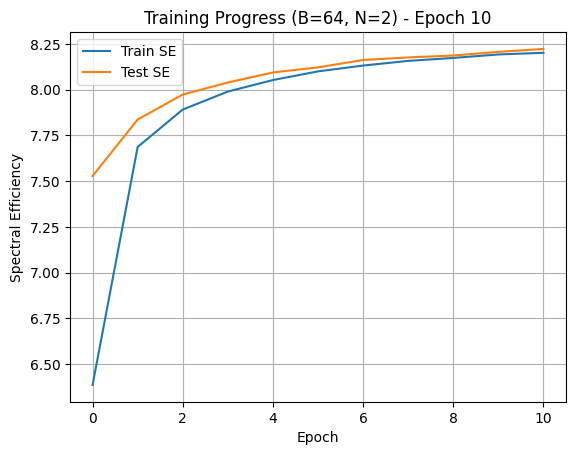

New best model saved with Test SE: 8.2222
Epoch: 11 | Time: 0:01:21.236037 | Train SE: 8.210 | Test SE: 8.223
New best model saved with Test SE: 8.2234
Epoch: 12 | Time: 0:01:21.083407 | Train SE: 8.229 | Test SE: 8.237
New best model saved with Test SE: 8.2369
Epoch: 13 | Time: 0:01:19.823373 | Train SE: 8.238 | Test SE: 8.253
New best model saved with Test SE: 8.2527
Epoch: 14 | Time: 0:01:20.931598 | Train SE: 8.251 | Test SE: 8.258
New best model saved with Test SE: 8.2577


In [ ]:
B = 64
train(Nc, N, Nt, B, Nr, L, SNR_dB, K, EPOCH, BATCH_SIZE)